# **Métodos Aproximados**
**Autores:** Gloria Casals y Ángel Franco

In [ ]:
# Clonamos el repositorio
!git clone https://github.com/AngelD222/CasalsFranco.git

Cloning into 'CasalsFranco'...
remote: Enumerating objects: 700, done.
remote: Counting objects: 100% (169/169), done.
remote: Compressing objects: 100% (167/167), done.
remote: Total 700 (delta 51), reused 1 (delta 1), pack-reused 531 (from 2)
Receiving objects: 100% (700/700), 175.87 KiB | 1.46 MiB/s, done.
Resolving deltas: 100% (208/208), done.


In [ ]:
# Instalación de dependencias
!pip install gymnasium tqdm matplotlib

import os
import sys
import gymnasium as gym
import matplotlib.pyplot as plt
import numpy as np

repo_name = 'CasalsFranco/entornos_complejos'

# Añadimos la ruta al sistema
if f'/content/{repo_name}' not in sys.path:
    sys.path.append(f'/content/{repo_name}')

print("Archivos en el directorio:")
!ls /content/{repo_name}

# Importamos nuestro framework modular
from src.utils import set_seed, make_env, train_agent, plot_episode_lengths, plot_multiple_seeds_rewards, plot_multiple_seeds_rewards2
from src.agents import AgentSarsaSemiGradient, AgentDQN, AgentSarsaSemiGradient2

# Fijamos las semillas para garantizar la reproducibilidad
SEMILLA = 2908
set_seed(SEMILLA)

Archivos en el directorio:
README.md  src
Usando dispositivo: cpu


## **Introducción al Entorno y Métodos Aproximados**



Para evaluar los algoritmos de aproximación de funciones hemos seleccionado el entorno **MountainCar-v0** de Gymnasium.


A diferencia de los entornos tabulares (como Blackjack o CliffWalking vistos en los otros notebooks), `MountainCar` presenta un **espacio de estados continuo** definido por dos variables: la posición del coche en el eje x $[-1.2, 0.6]$ y su velocidad $[-0.07, 0.07]$. Al ser un espacio continuo, el número de estados posibles es infinito, lo que imposibilita el uso de tablas $Q(S,A)$ exactas.

Además, presenta un desafío de recompensa dispersa (sparse reward): el agente recibe una recompensa de $-1$ en cada paso de tiempo, y el episodio solo termina (sin penalización extra) cuando el coche alcanza la meta (posición $\ge 0.5$). Al principio, las acciones del agente no parecen tener impacto en alcanzar la meta, lo que exige una política de exploración eficiente.

**Algoritmos a evaluar**

Para resolver este MDP (Proceso de decisión de Markov) continuo, implementaremos y compararemos dos algoritmos:

1. **SARSA Semi-gradiente (On-Policy):** Aproxima la función de valor-acción $\hat{q}(S, A, \mathbf{w})$. Al ser *on-policy*, el agente aprende sobre la misma política que está ejecutando (incluyendo sus acciones exploratorias). La variante de semi-gradiente congela el cálculo del gradiente en el objetivo (*target*) durante el *bootstrapping* para evitar inestabilidad matemática.

2. **Deep Q-Learning (Off-Policy):** A diferencia de SARSA, Q-Learning busca converger a la política óptima independientemente de la política de exploración que esté generando los datos. Para evitar la divergencia al combinar Off-policy + Bootstrapping + Aproximación implementaremos este agente con 2 innovaciones:
   * **Experience Replay (memoria de repetición):** Para romper la correlación temporal de las secuencias de estados.
   * **Target Network (red objetivo):** Para estabilizar el objetivo de actualización de los pesos de la red neuronal.


El objetivo del aprendizaje es encontrar una política $\pi$ que minimice la longitud del episodio $f(t)$, logrando que el coche acumule impulso balanceándose de izquierda a derecha para poder subir la colina.


**Justificación de la variante Discreta (MountainCar-v0) en vez de la Continua (MountainCarContinuous-v0):**

Aunque ambos comparten el mismo espacio de estados continuo (posición y velocidad), difieren en su espacio de acciones:
* `MountainCar-v0`: Tiene un espacio de acciones **discreto** con 3 valores posibles (0: Acelerar a la izquierda, 1: No hacer nada, 2: Acelerar a la derecha).
* `MountainCarContinuous-v0`: Tiene un espacio de acciones **continuo**, donde la acción es un valor real en el rango $[-1.0, 1.0]$ que representa la fuerza del motor.

**Limitación del entorno y los algoritmos:**
Nuestra elección está basada en las limitaciones de los algoritmos de control Value-Based que estamos evaluando. Tanto SARSA con política $\epsilon$-greedy como DQN dependen de encontrar la acción que maximiza el valor esperado: $\max_{a} Q(s, a)$.

En un espacio de acciones discreto solo evaluamos la red 3 veces o tenemos 3 neuronas de salida. Sin embargo en un espacio de acciones continuo, encontrar el máximo global de $Q(s, a)$ respecto a $a$ se vuelve un problema de optimización muy complejo. Para resolver `MountainCarContinuous-v0` de forma rigurosa, necesitaríamos implementar algoritmos del tipo Actor-Crítico continuo (como DDPG o SAC).


### **ESTUDIO 1: impacto de la tasa de exploración en SARSA Semi-gradiente**

#### **Agente 1**

En este apartado vamos a analizar el impacto de la tasa de decaimiento de $\epsilon$ en SARSA Semi-gradiente ante un problema de recompensa dispersa.

En `MountainCar` el agente recibe $-1$ de recompensa en cada paso. La señal de éxito (llegar a la bandera) está muy lejos en las trayectorias iniciales. Si la política $\epsilon$-greedy decae hacia la explotación demasiado rápido, el agente se quedará atascado en el fondo del valle minimizando movimientos cortos, convergiendo a un óptimo local (o simplemente agotando los 200 pasos máximos del entorno).



Vamos a comparar tres configuraciones distintas de la política $\epsilon$-greedy usando nuestro agente `AgentSarsaSemiGradient`:

1. **Decay Lento ($\text{tasa}=0.005$):** Mantiene la exploración durante el tiempo suficiente para descubrir la meta y luego converge a la explotación.

2. **Decay Rápido ($\text{tasa}=0.05$):** Corta la exploración rápidamente. Hipotetizamos que el agente quedará atrapado en mínimos locales.

3. **Exploración Constante ($\epsilon=0.1$ fijo):** Mantiene un 10% de aleatoriedad constante.

*(Promediaremos $N=3$ semillas independientes para cada configuración).*


=== Evaluando configuración: Decay Lento (0.005) ===
Usando dispositivo: cpu


Entrenando agente:   0%|          | 0/600 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Entrenando agente: 100%|██████████| 600/600 [04:21<00:00,  2.29it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [04:04<00:00,  2.46it/s]


Usando dispositivo: cpu


...

Entrenando agente: 100%|██████████| 600/600 [03:58<00:00,  2.51it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [03:53<00:00,  2.56it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [03:59<00:00,  2.50it/s]


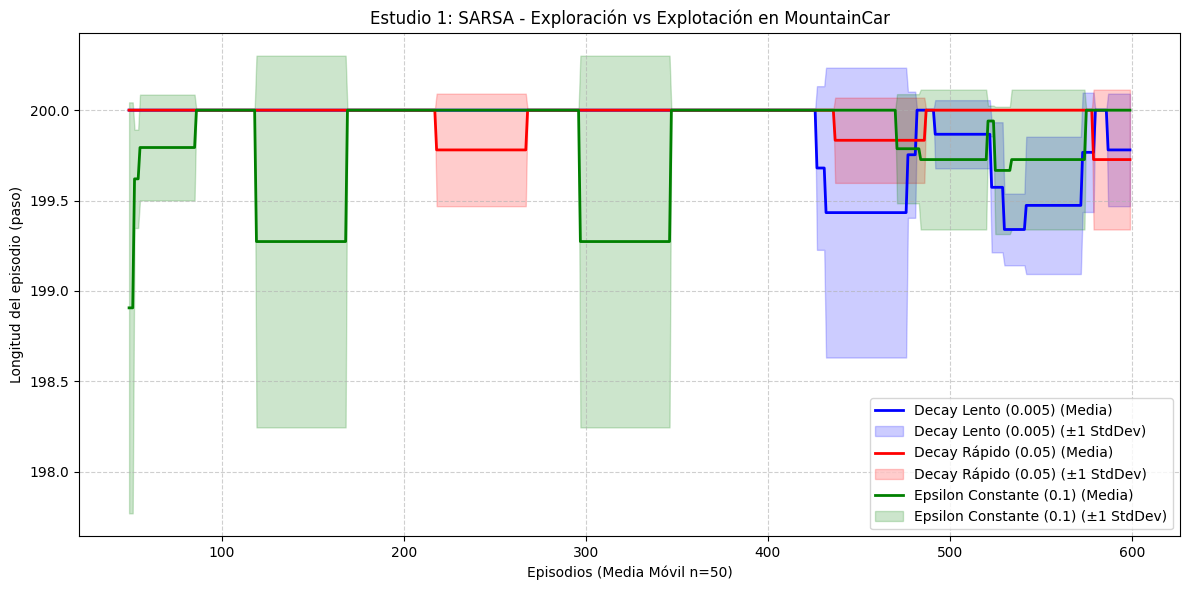

In [ ]:
# Estudio 1: Exploración en SARSA Semi-gradiente

n_semillas = 3
episodios = 600
semillas = [1, 12, 123]

# Configuraciones a testear: (initial_eps, final_eps, decay_rate)
configuraciones_eps = {
    "Decay Lento (0.005)": {"init": 1.0, "final": 0.01, "decay": 0.005},
    "Decay Rápido (0.05)": {"init": 1.0, "final": 0.01, "decay": 0.05},
    "Epsilon Constante (0.1)": {"init": 0.1, "final": 0.1, "decay": 0.0} # Al ser init=final, no hay decay real
}

resultados_estudio_1 = {}

for nombre_config, params in configuraciones_eps.items():
    print(f"\n=== Evaluando configuración: {nombre_config} ===")
    matriz_resultados = np.zeros((n_semillas, episodios))

    for i, seed in enumerate(semillas):
        set_seed(seed)
        env = make_env("MountainCar-v0", seed=seed)

        # Agente SARSA con hiperparámetros base
        hyperparams = {'gamma': 0.99, 'lr': 0.001, 'epsilon': params["init"]}
        agent_sarsa = AgentSarsaSemiGradient(env, hyperparams)

        # Entrenamos inyectando los parámetros específicos de esta configuración
        stats = train_agent(
            env=env,
            agent=agent_sarsa,
            n_episodes=episodios,
            initial_eps=params["init"],
            final_eps=params["final"],
            decay_rate=params["decay"]
        )

        # Guardamos la métrica f(t) = longitud del episodio
        matriz_resultados[i] = stats["episode_lengths"]
        env.close()

    resultados_estudio_1[nombre_config] = matriz_resultados

# Visualizamos la comparativa con su varianza
plot_multiple_seeds_rewards2(
    resultados_estudio_1,
    window_size=50,
    title="Estudio 1: SARSA - Exploración vs Explotación en MountainCar"
)

* **Decay Rápido** (0.05) : Fracasa totalmente, manteniendo una media de 200 pasos sin apenas varianza. Reducir rápidamente la exploración en entornos de recompensa dispersa impide descubrir la meta, forzando al agente a convergir a una política subóptima al no poder propagar los valores $Q(S,A)$.

* **Decay Lento** (0.005) : Desciende levemente en el episodio 250, logrando éxitos esporádicamente. No obstante el rendimiento global sigue siendo malo. Quizá esto evidencia que 600 episodios son insuficientes para propagar los valores $Q$, o que la parametrización actual no permite aprovechar esta exploración prolongada.

* **Epsilon Constante** (0.1) : Aunque muestra la mejor media (por debajo de 199), el resultado continua siendo malo. La teoría predice que una política $\epsilon$-greedy estática genera inestabilidad severa, lo cual se refleja en su gran varianza.


Por tanto, aunque el decaimiento rápido falla por falta de exploración, tanto el decaimiento lento como la exploración constante dan resultados muy malos en este margen de 600 episodios. Para lograr que la curva de pasos converja hacia un número de pasos menor, podríamos incrementar significativamente el número de episodios (aunque vistos estos resultados seguramente esto no será de utilidad) o intentar ajustar parámetros de aprendizaje.



#### **Evaluacion Agente 1, 600 episodios**

Vistos los resultados de entrenamiento, está claro que en evaluación SARSA semi gradiente con las distintas políticas mostrará que no ha aprendido a resolver el entorno y obtendremos una longitud de episodio de 200.

In [ ]:
def evaluate_agent(env, agent, n_episodes=100):
    agent.epsilon = 0.0 # Explotación pura
    episode_lengths = []

    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        length = 0

        while not done:
            action = agent.get_action(obs)
            next_obs, _, terminated, truncated, _ = env.step(action)
            length += 1
            done = terminated or truncated
            obs = next_obs

        episode_lengths.append(length)

    return episode_lengths # Devuelve estrictamente una lista plana de números


Fase de Evaluación Estudio 1, Agente 1

Entrenando campeón de 'Decay Lento (0.005)' para evaluación...
Usando dispositivo: cpu


Entrenando agente:   0%|          | 0/600 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Entrenando agente: 100%|██████████| 600/600 [03:51<00:00,  2.60it/s]


Evaluando Decay Lento (0.005)...
Usando dispositivo: cpu

Entrenando campeón de 'Decay Rápido (0.05)' para evaluación...
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [03:50<00:00,  2.61it/s]


Evaluando Decay Rápido (0.05)...
Usando dispositivo: cpu

Entrenando campeón de 'Epsilon Constante (0.1)' para evaluación...
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [03:52<00:00,  2.58it/s]


Evaluando Epsilon Constante (0.1)...
Usando dispositivo: cpu

=== Resultados de la Evaluación (100 Episodios, Epsilon=0) ===
Decay Lento (0.005): Media = 200.00 pasos | Std = 0.00 | Mejor = 200 pasos
Decay Rápido (0.05): Media = 200.00 pasos | Std = 0.00 | Mejor = 200 pasos
Epsilon Constante (0.1): Media = 200.00 pasos | Std = 0.00 | Mejor = 200 pasos


/tmp/ipython-input-172/403583631.py:47: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados_eval_estudio1.values(), labels=resultados_eval_estudio1.keys())


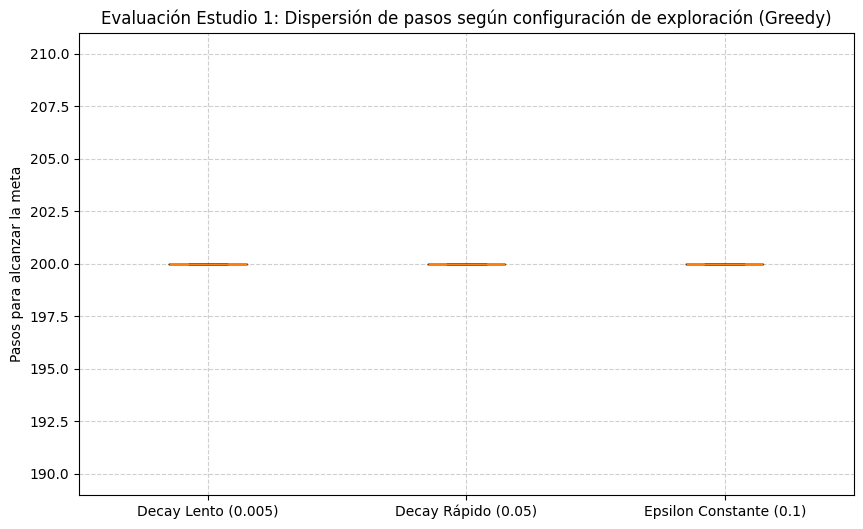

In [ ]:

# EVALUACIÓN ESTUDIO 1: 100 Episodios (epsilon = 0)

print("\nFase de Evaluación Estudio 1, Agente 1")

n_eval_episodes = 100
resultados_eval_estudio1 = {}
env_eval = make_env("MountainCar-v0", seed=1) # Semilla de testing

for nombre_config, params in configuraciones_eps.items():
    print(f"\nEntrenando campeón de '{nombre_config}' para evaluación...")

    # 1. Entrenamos al Campeón con semilla fija
    set_seed(29)
    env_train = make_env("MountainCar-v0", seed=29)

    hyperparams = {'gamma': 0.99, 'lr': 0.001, 'epsilon': params["init"]}
    agente_campeon = AgentSarsaSemiGradient(env_train, hyperparams)

    train_agent(
        env=env_train,
        agent=agente_campeon,
        n_episodes=600,
        initial_eps=params["init"],
        final_eps=params["final"],
        decay_rate=params["decay"]
    )
    env_train.close()

    # 2. Lo evaluamos (100 episodios sin explorar, epsilon=0)
    print(f"Evaluando {nombre_config}...")
    set_seed(1)
    lengths = evaluate_agent(env_eval, agente_campeon, n_episodes=n_eval_episodes)
    resultados_eval_estudio1[nombre_config] = lengths

env_eval.close()

# === IMPRESIÓN DE RESULTADOS ESTADÍSTICOS ===
print("\n=== Resultados de la Evaluación (100 Episodios, Epsilon=0) ===")
for nombre, lengths in resultados_eval_estudio1.items():
    media = np.mean(lengths)
    std = np.std(lengths)
    minimo = np.min(lengths)
    print(f"{nombre}: Media = {media:.2f} pasos | Std = {std:.2f} | Mejor = {minimo} pasos")

# === GRÁFICA: BOXPLOT ===
plt.figure(figsize=(10, 6))
plt.boxplot(resultados_eval_estudio1.values(), labels=resultados_eval_estudio1.keys())
plt.title("Evaluación Estudio 1: Dispersión de pasos según configuración de exploración (Greedy)")
plt.ylabel("Pasos para alcanzar la meta")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Tal y como sugerían las curvas de entrenamiento, la fase de evaluación confirma que SARSA Semi-gradiente no logra resolver el entorno bajo ninguna de las estrategias de exploración probadas.

**Vamos a ver que ocurre en el caso de doblar el número de episodios en entrenamiento a 1200:**


=== Evaluando configuración: Decay Lento (0.005) ===
Usando dispositivo: cpu


Entrenando agente:   0%|          | 0/1200 [00:00<?, ?it/s]/usr/local/lib/python3.12/dist-packages/torch/nn/modules/loss.py:626: UserWarning: Using a target size (torch.Size([1])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.mse_loss(input, target, reduction=self.reduction)
Entrenando agente: 100%|██████████| 1200/1200 [07:08<00:00,  2.80it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 1200/1200 [07:08<00:00,  2.80it/s]


Usando dispositivo: cpu


...

Entrenando agente: 100%|██████████| 1200/1200 [07:17<00:00,  2.74it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 1200/1200 [07:05<00:00,  2.82it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 1200/1200 [07:08<00:00,  2.80it/s]


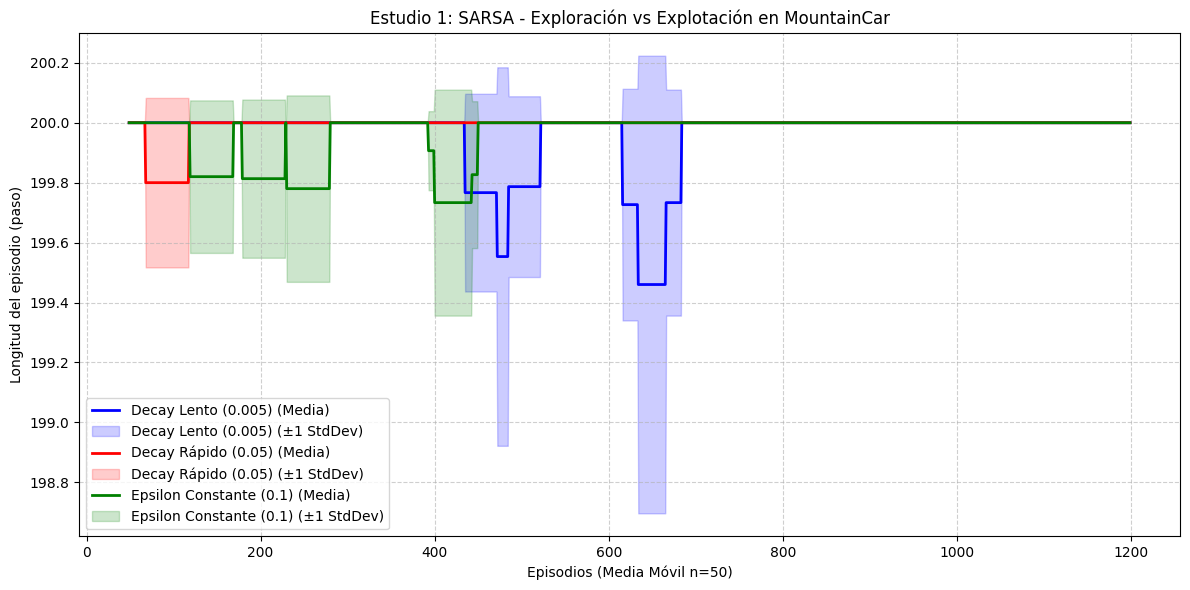

In [ ]:
# Estudio 1: Exploración en SARSA Semi-gradiente
n_semillas = 3
episodios = 1200
semillas = [1, 12, 123]

# Configuraciones a testear: (initial_eps, final_eps, decay_rate)
configuraciones_eps = {
    "Decay Lento (0.005)": {"init": 1.0, "final": 0.01, "decay": 0.005},
    "Decay Rápido (0.05)": {"init": 1.0, "final": 0.01, "decay": 0.05},
    "Epsilon Constante (0.1)": {"init": 0.1, "final": 0.1, "decay": 0.0} # Al ser init=final, no hay decay real
}

resultados_estudio_1 = {}

for nombre_config, params in configuraciones_eps.items():
    print(f"\n=== Evaluando configuración: {nombre_config} ===")
    matriz_resultados = np.zeros((n_semillas, episodios))

    for i, seed in enumerate(semillas):
        set_seed(seed)
        env = make_env("MountainCar-v0", seed=seed)

        # Agente SARSA con hiperparámetros base
        hyperparams = {'gamma': 0.99, 'lr': 0.001, 'epsilon': params["init"]}
        agent_sarsa = AgentSarsaSemiGradient(env, hyperparams)

        # Entrenamos inyectando los parámetros específicos de esta configuración
        stats = train_agent(
            env=env,
            agent=agent_sarsa,
            n_episodes=episodios,
            initial_eps=params["init"],
            final_eps=params["final"],
            decay_rate=params["decay"]
        )

        # Guardamos la métrica f(t) = longitud del episodio
        matriz_resultados[i] = stats["episode_lengths"]
        env.close()

    resultados_estudio_1[nombre_config] = matriz_resultados

# Visualizamos la comparativa con su varianza
plot_multiple_seeds_rewards2(
    resultados_estudio_1,
    window_size=50,
    title="Estudio 1: SARSA - Exploración vs Explotación en MountainCar"
)

Observando la evolución de la longitud del episodio vemos que los agentes no logran resolver el entorno en las 1200 iteraciones evaluadas. En todas las configuraciones de exploración puestas a prueba el número de pasos se mantiene en una media móvil constante de 200 a largo plazo.

La incapacidad de aprender sugiere que el cuello de botella no reside en el parámetro $\epsilon$, sino en los hiperparámetros base del *AgentSarsaSemiGradient* y en su configuración interna.

#### **Agente 2**

A la vista del fracaso en la convergencia del primer estudio, **introducimos una versión corregida del agente para abordar tres problemas detectados:**

- Primero, se ha implementado la normalización Min-Max del espacio de estados al intervalo $[-1, 1]$ para evitar que la magnitud de la posición domine sobre la velocidad en los gradientes de la red.

- Segundo, se ha corregido el cálculo del objetivo TD (TD-target), diferenciando terminated de truncated, lo que permite mantener el bootstrapping cuando el episodio se corta por límite de tiempo y evita sesgar la función de valor $Q(s,a)$ hacia el 0.

- Por último se ha reducido la tasa de aprendizaje ($\alpha = 0.0005$).


=== Evaluando configuración: Decay Lento (0.005) ===
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [03:28<00:00,  2.87it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [03:42<00:00,  2.70it/s]


Usando dispositivo: cpu


...

Entrenando agente: 100%|██████████| 600/600 [03:27<00:00,  2.89it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [03:26<00:00,  2.90it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [03:28<00:00,  2.88it/s]


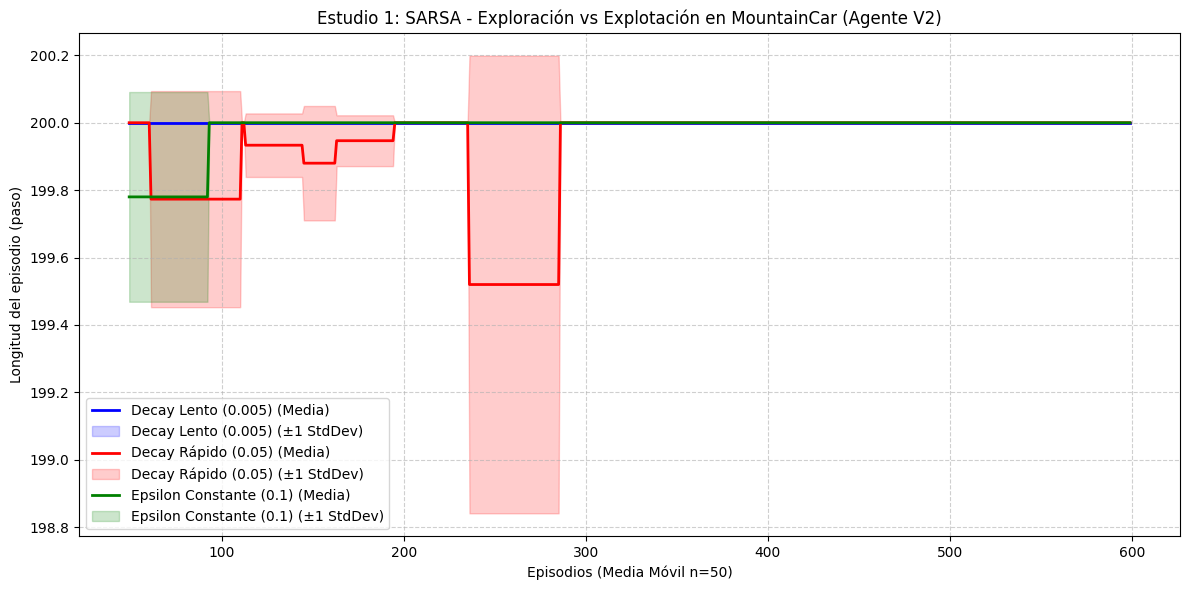

In [ ]:


# Estudio 1: Exploración en SARSA Semi-gradiente con la 2ª versión
n_semillas = 3
episodios = 600
semillas = [1, 12, 123]

# Configuraciones a testear: (initial_eps, final_eps, decay_rate)
configuraciones_eps = {
    "Decay Lento (0.005)": {"init": 1.0, "final": 0.01, "decay": 0.005},
    "Decay Rápido (0.05)": {"init": 1.0, "final": 0.01, "decay": 0.05},
    "Epsilon Constante (0.1)": {"init": 0.1, "final": 0.1, "decay": 0.0} # Al ser init=final, no hay decay real
}

resultados_estudio_1 = {}

for nombre_config, params in configuraciones_eps.items():
    print(f"\n=== Evaluando configuración: {nombre_config} ===")
    matriz_resultados = np.zeros((n_semillas, episodios))

    for i, seed in enumerate(semillas):
        set_seed(seed) # Asegurar reproducibilidad (PyTorch, Numpy, Gym)
        env = make_env("MountainCar-v0", seed=seed)

        # Agente SARSA con hiperparámetros corregidos (lr=0.0005)
        hyperparams = {'gamma': 0.99, 'lr': 0.0005, 'epsilon': params["init"]}

        # USAMOS EL NUEVO AGENTE
        agent_sarsa = AgentSarsaSemiGradient2(env, hyperparams)

        # Entrenamos inyectando los parámetros específicos de esta configuración
        stats = train_agent(
            env=env,
            agent=agent_sarsa,
            n_episodes=episodios,
            initial_eps=params["init"],
            final_eps=params["final"],
            decay_rate=params["decay"]
        )

        # Guardamos la métrica f(t) = longitud del episodio (pasos)
        matriz_resultados[i] = stats["episode_lengths"]
        env.close()

    resultados_estudio_1[nombre_config] = matriz_resultados

# Visualizamos la comparativa con su varianza usando la función paramétrica
plot_multiple_seeds_rewards2(
    data_dict=resultados_estudio_1,
    window_size=50,
    title="Estudio 1: SARSA - Exploración vs Explotación en MountainCar (Agente V2)"
)

A la luz de los resultados obtenidos tras aplicar las correcciones al agente, observamos que la longitud del episodio se mantiene de nuevo en el límite máximo de 200. Este comportamiento demuestra empíricamente que el uso de una red neuronal mediante actualizaciones online y paso a paso es inadecuado para este entorno. La correlación temporal de las secuencias del MDP provoca que la red sufra de olvido catastrófico y que no generalice la función de valor $Q(s,a)$.

Por tanto, concluimos en este primer estudio que la configuración de hiperparámetros o del balance exploración-explotación ($\epsilon$-greedy) resulta insuficiente. Esto justifica la necesidad de que introduzcamos otros algoritmos que logren romper esta correlación temporal, como será el caso de DQN que veremos a continuación.

### **ESTUDIO 2: comparando SARSA y DQN**

#### **Fase de entrenamiento**

Comparamos el rendimiento promedio y la varianza entre SARSA (On-policy) y DQN (Off-policy), evaluando sobre 3 semillas aleatorias diferentes durante 500 episodios:

* **SARSA Semi-gradiente:** Aprende de manera *on-policy*, sin memoria de repetición.

* **DQN:** Aprende de manera *off-policy*, utilizando un *replay buffer* para decorrelacionar las muestras y una *target network* para estabilizar los objetivos de actualización.





=== Entrenando SARSA (On-Policy) ===
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 1500/1500 [09:20<00:00,  2.67it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 1500/1500 [08:55<00:00,  2.80it/s]


Usando dispositivo: cpu


...

Entrenando agente: 100%|██████████| 1500/1500 [10:51<00:00,  2.30it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 1500/1500 [10:52<00:00,  2.30it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 1500/1500 [10:28<00:00,  2.39it/s]


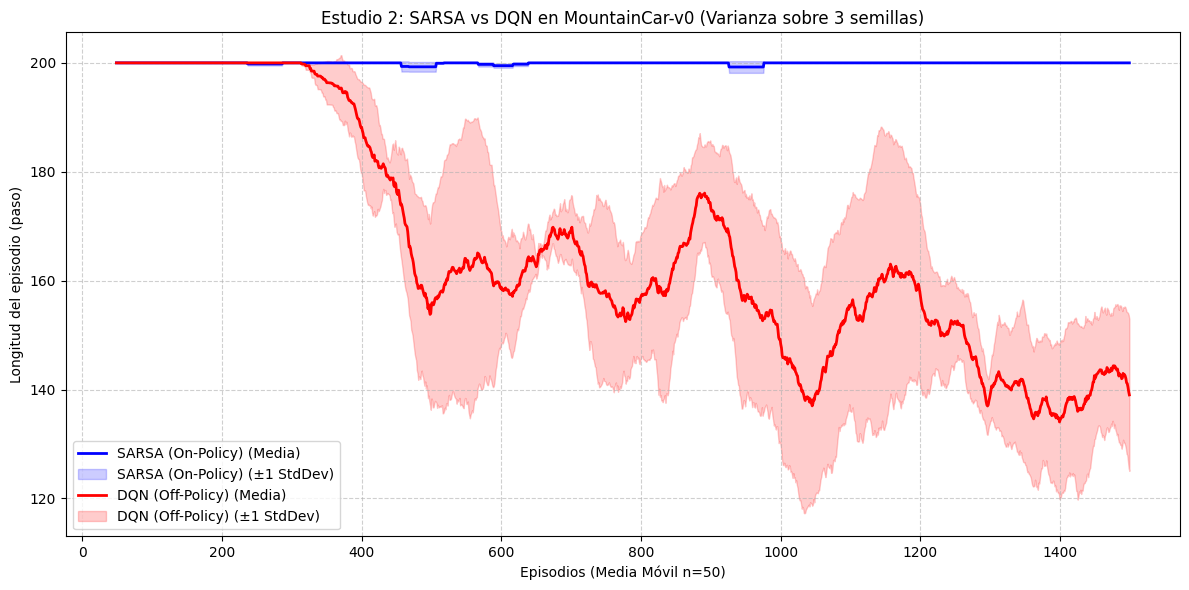

In [ ]:
# Estudio 2: SARSA vs DQN

n_semillas = 3
episodios = 1500
semillas = [1, 12, 123]

resultados_estudio_2 = {}

# Configuraciones de los algoritmos
algoritmos = {
    "SARSA (On-Policy)": (AgentSarsaSemiGradient, {'gamma': 0.99, 'lr': 0.001}),
    "DQN (Off-Policy)": (AgentDQN, {
        'gamma': 0.99,
        'lr': 0.001,
        'batch_size': 64,
        'target_update_freq': 200,
        'buffer_capacity': 10000
    })
}

for nombre_algo, (clase_agente, hyperparams) in algoritmos.items():
    print(f"\n=== Entrenando {nombre_algo} ===")
    matriz_resultados = np.zeros((n_semillas, episodios))

    for i, seed in enumerate(semillas):
        set_seed(seed)
        env = make_env("MountainCar-v0", seed=seed)

        # Inicializamos el hiperparámetro epsilon base
        hyperparams['epsilon'] = 1.0
        agente = clase_agente(env, hyperparams)

        # Entrenamos (Decay de 0.01 para asegurar buena exploración inicial en ambos)
        stats = train_agent(
            env=env,
            agent=agente,
            n_episodes=episodios,
            initial_eps=1.0,
            final_eps=0.01,
            decay_rate=0.01
        )

        matriz_resultados[i] = stats["episode_lengths"]
        env.close()

    resultados_estudio_2[nombre_algo] = matriz_resultados



# Visualización comparativa
plot_multiple_seeds_rewards2(
    resultados_estudio_2,
    window_size=50,
    title="Estudio 2: SARSA vs DQN en MountainCar-v0 (Varianza sobre 3 semillas)"
)



Como era de esperar por los resultados obtenidos anteriormente, la curva de SARSA se mantiene plana en el límite superior de 200 pasos, mientras que la curva de DQN muestra un aprendizaje claro, comenzando a reducir la longitud del episodio significativamente a partir de la iteración 300 y convergiendo hacia un rendimiento estable de $\approx$ 140 pasos en las últimas iteraciones.

DQN, con el Experience Replay, al almacenar transiciones y entrenar sobre mini-batches aleatorios evita la fuerte correlación temporal de las secuencias del MDP, estabilizando el gradiente de la red neuronal.


#### **Fase de evaluación**

In [ ]:
def evaluate_agent(env, agent, n_episodes=100):
    """
    Evalúa un agente congelando su aprendizaje y forzando epsilon = 0.
    """
    agent.epsilon = 0.0 # Explotación pura (Greedy)

    # Buenas prácticas PyTorch: Poner la red en modo evaluación si existe
    if hasattr(agent, 'q_network'):
        agent.q_network.eval()

    episode_lengths = []
    successes = 0 # Contador de victorias

    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        length = 0

        while not done:
            action = agent.get_action(obs)
            # Solo avanzamos, NO llamamos a agent.update()
            next_obs, _, terminated, truncated, _ = env.step(action)

            length += 1
            done = terminated or truncated
            obs = next_obs

        episode_lengths.append(length)
        # En MountainCar, si llega en menos de 200 pasos, es un éxito
        if length < 200:
            successes += 1

    # Restaurar la red a modo entrenamiento por si acaso
    if hasattr(agent, 'q_network'):
        agent.q_network.train()

    success_rate = (successes / n_episodes) * 100
    return episode_lengths, success_rate


=== Iniciando Fase de Evaluación Final ===

Entrenando campeón de SARSA (On-Policy) para evaluación...
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 750/750 [04:20<00:00,  2.88it/s]


Evaluando SARSA (On-Policy)...
Usando dispositivo: cpu
-> SARSA (On-Policy): Tasa de Éxito = 0.0% | Media = 200.00 | Std = 0.00 | Mejor = 200

Entrenando campeón de DQN (Off-Policy) para evaluación...
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 750/750 [05:21<00:00,  2.34it/s]


Evaluando DQN (Off-Policy)...
Usando dispositivo: cpu
-> DQN (Off-Policy): Tasa de Éxito = 100.0% | Media = 133.68 | Std = 32.85 | Mejor = 88


/tmp/ipython-input-315/2717239868.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  box = plt.boxplot(data, labels=labels, patch_artist=True)


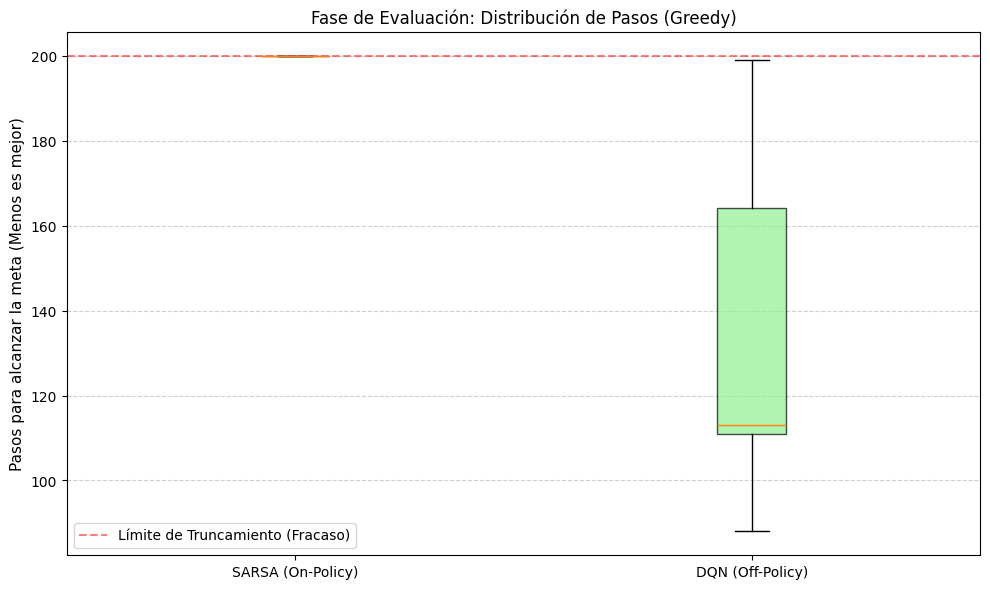

In [ ]:
def plot_evaluation_boxplot(resultados_evaluacion: Dict[str, list], title: str = "Fase de Evaluación: Distribución de Pasos (Greedy)"):
    """
    Dibuja un boxplot para comparar el rendimiento estocástico de políticas deterministas (epsilon=0).
    """
    plt.figure(figsize=(10, 6))

    # Extraer nombres de algoritmos y sus respectivas listas de pasos
    labels = list(resultados_evaluacion.keys())
    data = list(resultados_evaluacion.values())

    # Crear el boxplot
    box = plt.boxplot(data, labels=labels, patch_artist=True)

    # Colorear las cajas para que quede estético
    colores = ['lightblue', 'lightgreen', 'lightcoral', 'thistle']
    for patch, color in zip(box['boxes'], colores):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    plt.title(title, fontsize=12)
    plt.ylabel("Pasos para alcanzar la meta (Menos es mejor)", fontsize=11)
    # Marcar el límite de fracaso (200 pasos)
    plt.axhline(y=200, color='red', linestyle='--', alpha=0.5, label='Límite de Truncamiento (Fracaso)')
    plt.legend()
    plt.grid(True, axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


# =====================================================================
# SECCIÓN DE EVALUACIÓN FINAL: 100 Episodios (Greedy / epsilon = 0)
# =====================================================================


print("\n=== Iniciando Fase de Evaluación Final ===")

n_eval_episodes = 100
resultados_evaluacion = {}
env_eval = make_env("MountainCar-v0", seed=999)

for nombre_algo, (clase_agente, hyperparams) in algoritmos.items():
    print(f"\nEntrenando campeón de {nombre_algo} para evaluación...")

    # 1. Entrenamos al campeón
    set_seed(42)
    env_train = make_env("MountainCar-v0", seed=42)
    hyperparams['epsilon'] = 1.0
    agente_campeon = clase_agente(env_train, hyperparams)

    train_agent(
        env=env_train,
        agent=agente_campeon,
        n_episodes=750,
        initial_eps=1.0,
        final_eps=0.01,
        decay_rate=0.01
    )
    env_train.close()

    # 2. Lo evaluamos
    print(f"Evaluando {nombre_algo}...")
    set_seed(999)
    lengths, success_rate = evaluate_agent(env_eval, agente_campeon, n_episodes=n_eval_episodes)

    resultados_evaluacion[nombre_algo] = lengths

    #  IMPRESIÓN DE ESTADÍSTICOS INDIVIDUALES
    media = np.mean(lengths)
    std = np.std(lengths)
    minimo = np.min(lengths)
    print(f"-> {nombre_algo}: Tasa de Éxito = {success_rate}% | Media = {media:.2f} | Std = {std:.2f} | Mejor = {minimo}")

env_eval.close()

# GRÁFICA FINAL
plot_evaluation_boxplot(resultados_evaluacion)

Para validar el rendimiento de los algoritmos tras su fase de entrenamiento, hemos realizado una fase de evaluación de 100 episodios independientes.

* SARSA presenta una tasa de éxito nula, quedándose en el límite de truncamiento de 200 pasos. Por el contrario, DQN alcanza una tasa de éxito perfecta, resolviendo el entorno en todos los episodios de prueba antes del límite de tiempo. La mediana de la longitud del episodio se sitúa en torno a los 110 pasos. Resulta destacable que el mejor episodio registrado por DQN le ha llevado 88 pasos.

### **ESTUDIO 3: estudio del Experience Replay en DQN**

En la segunda edición de 2018 del libro *Reinforcement Learning: An Introduction* de Richard S. Sutton y Andrew G. Barto, se menciona en el Capítulo 11 (Off-policy Methods with Approximation), lo que llaman el “deadly triad”, cuando juntamos:

- Aproximación de Funciones (red neuronal)

- Bootstrapping (aprender de estimaciones)

- Entrenamiento Off-Policy

Al combinar esto, el algoritmo se vuelve inestable y los pesos de la red pueden diverger al infinito. El Experience Replay Buffer de DQN mitiga esto rompiendo la alta correlación temporal de los estados en un MDP (el estado $S_{t+1}$ es casi idéntico a $S_t$). Si reducimos la memoria, obligamos a la red a entrenar con minibatches de datos secuenciales, y de nuevo aparece este problema.

Vamos a realizar un estudio donde limitaremos la capacidad del buffer.

1. **DQN estándar (Buffer = 10,000):** La red muestrea minibatches de un gran historial decorrelacionado.

2. **DQN simplificado (Buffer = 100):** La red se ve obligada a entrenar únicamente con las transiciones más recientes. Al usar un batch size de 64 casi todo el batch estará compuesto por pasos fuertemente correlacionados de la misma trayectoria temporal.



=== Evaluando DQN (Buffer = 10000) - Estable ===
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 400/400 [03:14<00:00,  2.06it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 400/400 [03:11<00:00,  2.09it/s]


Usando dispositivo: cpu


...

Entrenando agente: 100%|██████████| 400/400 [03:13<00:00,  2.07it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 400/400 [03:15<00:00,  2.04it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 400/400 [03:16<00:00,  2.04it/s]


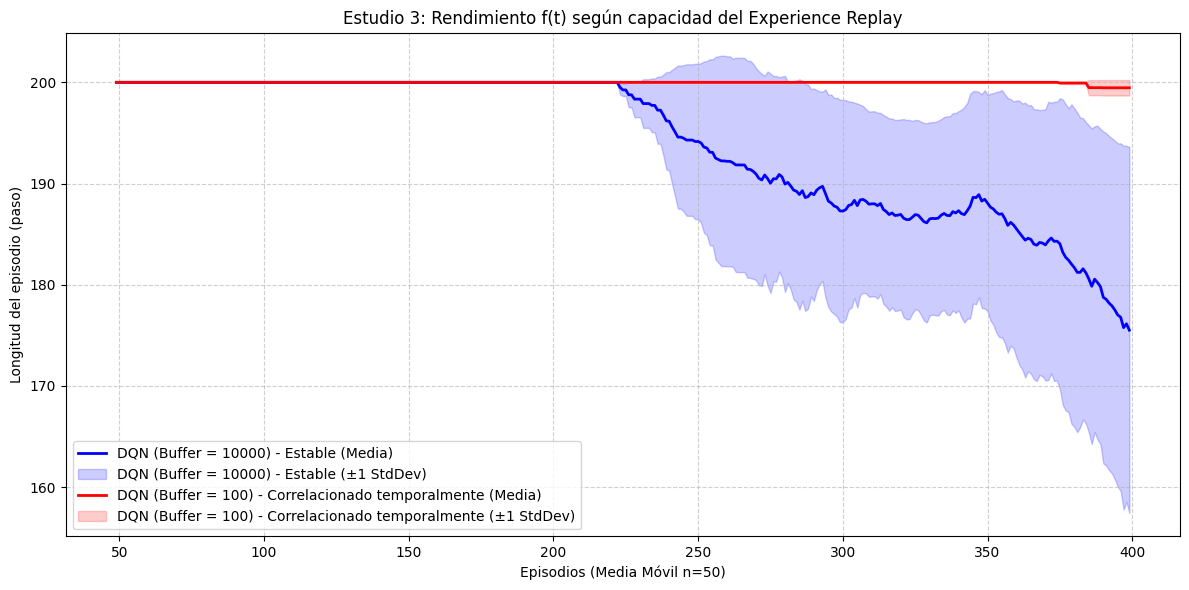

In [ ]:
# Estudio 3: tocando Experience Replay

n_semillas = 3
episodios = 400  # Con 400 episodios es suficiente para ver la divergencia
semillas = [1, 12, 123]

resultados_estudio_3 = {}
losses_estudio_3 = {} # Diccionario para guardar el Error (Loss)

# Configuraciones de capacidad de memoria
configuraciones_buffer = {
    "DQN (Buffer = 10000) - Estable": 10000,
    "DQN (Buffer = 100) - Correlacionado temporalmente": 100
}

for nombre_conf, capacidad in configuraciones_buffer.items():
    print(f"\n=== Evaluando {nombre_conf} ===")
    matriz_resultados = np.zeros((n_semillas, episodios))
    matriz_losses = np.zeros((n_semillas, episodios)) # Matriz para el Loss

    for i, seed in enumerate(semillas):
        set_seed(seed)
        env = make_env("MountainCar-v0", seed=seed)

        # Inyectamos la capacidad simplificada o estándar
        hyperparams = {
            'gamma': 0.99,
            'lr': 0.001,
            'batch_size': 64,
            'target_update_freq': 200,
            'buffer_capacity': capacidad,
            'epsilon': 1.0
        }
        # Usamos nuestra subclase aislada
        agente = AgentDQN(env, hyperparams)

        # Entrenamos
        stats = train_agent(
            env=env,
            agent=agente,
            n_episodes=episodios,
            initial_eps=1.0,
            final_eps=0.01,
            decay_rate=0.01
        )

        matriz_resultados[i] = stats["episode_lengths"]
        env.close()

    resultados_estudio_3[nombre_conf] = matriz_resultados
    losses_estudio_3[nombre_conf] = matriz_losses # Lo añadimos al diccionario de losses




plot_multiple_seeds_rewards2(
    resultados_estudio_3,
    window_size=50,
    title="Estudio 3: Rendimiento f(t) según capacidad del Experience Replay"
)


La configuración con alta capacidad de memoria logra aprender una política subóptima rápida (descendiendo a $\approx$ 175 pasos en 400 episodios), y cuando la capacidad del buffer se limita a 100, el agente fracasa en su aprendizaje, manteniéndose en 200 pasos y solamente descendiendo ligeramente en las últimas iteraciones

Al alimentar la red neuronal con estados con gran correlación temporal, la optimización de los pesos se sobreajusta a la dinámica local de esa región del espacio de estados, provocando lo que se conoce como olvido catastrófico de las dinámicas aprendidas en regiones previas.

#### **Evaluación**

In [ ]:
def evaluate_agent(env, agent, n_episodes=100):
    """
    Evalúa un agente congelando su aprendizaje y forzando epsilon = 0.
    """
    agent.epsilon = 0.0 # Explotación pura (Greedy)

    # Buenas prácticas PyTorch: Poner la red en modo evaluación si existe
    if hasattr(agent, 'q_network'):
        agent.q_network.eval()
    elif hasattr(agent, 'policy_net'): # <--- Añadido para que funcione con DQN
        agent.policy_net.eval()

    episode_lengths = []
    successes = 0 # Contador de victorias

    for _ in range(n_episodes):
        obs, _ = env.reset()
        done = False
        length = 0

        while not done:
            action = agent.get_action(obs)
            # Solo avanzamos, NO llamamos a agent.update()
            next_obs, _, terminated, truncated, _ = env.step(action)

            length += 1
            done = terminated or truncated
            obs = next_obs

        episode_lengths.append(length)
        # En MountainCar, si llega en menos de 200 pasos, es un éxito
        if length < 200:
            successes += 1

    # Restaurar la red a modo entrenamiento por si acaso
    if hasattr(agent, 'q_network'):
        agent.q_network.train()
    elif hasattr(agent, 'policy_net'):
        agent.policy_net.train()

    success_rate = (successes / n_episodes) * 100
    return episode_lengths, success_rate


Fase de Evaluación Estudio 3

Entrenando campeón de 'DQN (Buffer = 10000) - Estable' para evaluación...
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 400/400 [03:19<00:00,  2.00it/s]


Evaluando DQN (Buffer = 10000) - Estable...
Usando dispositivo: cpu
-> Tasa de Éxito de DQN (Buffer = 10000) - Estable: 100.0%

Entrenando campeón de 'DQN (Buffer = 100) - Correlacionado temporalmente' para evaluación...
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 400/400 [03:14<00:00,  2.05it/s]


Evaluando DQN (Buffer = 100) - Correlacionado temporalmente...
Usando dispositivo: cpu
-> Tasa de Éxito de DQN (Buffer = 100) - Correlacionado temporalmente: 0.0%

=== Resultados de la Evaluación (100 Episodios, Epsilon=0) ===
DQN (Buffer = 10000) - Estable: Media = 123.99 pasos | Std = 30.88 | Mejor = 84 pasos
DQN (Buffer = 100) - Correlacionado temporalmente: Media = 200.00 pasos | Std = 0.00 | Mejor = 200 pasos


/tmp/ipython-input-172/1012840111.py:52: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(resultados_eval_estudio3.values(), labels=resultados_eval_estudio3.keys())


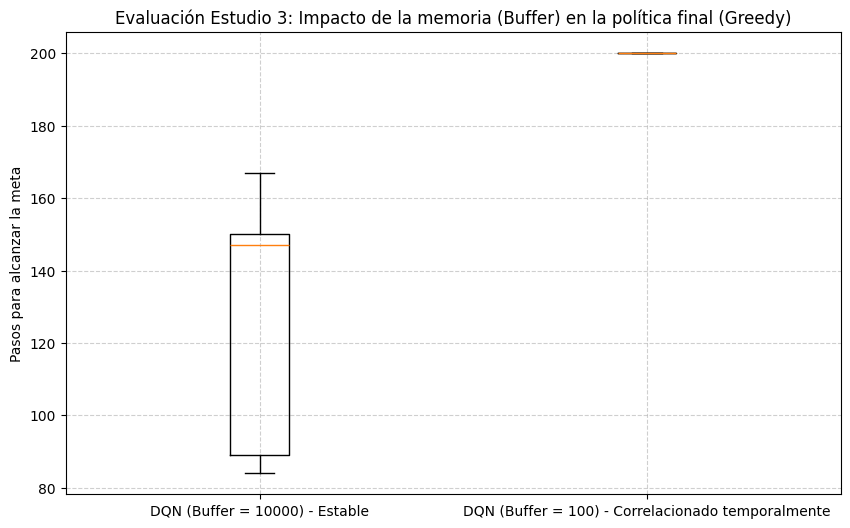

In [ ]:
print("\nFase de Evaluación Estudio 3")

n_eval_episodes = 100
resultados_eval_estudio3 = {}
env_eval = make_env("MountainCar-v0", seed=1) # Semilla de testing

for nombre_conf, capacidad in configuraciones_buffer.items():
    print(f"\nEntrenando campeón de '{nombre_conf}' para evaluación...")

    # 1. Entrenamos al Campeón con semilla fija
    set_seed(29)
    env_train = make_env("MountainCar-v0", seed=29)

    hyperparams = {
        'gamma': 0.99, 'lr': 0.001, 'batch_size': 64,
        'target_update_freq': 200, 'buffer_capacity': capacidad, 'epsilon': 1.0
    }
    agente_campeon = AgentDQN(env_train, hyperparams)

    train_agent(
        env=env_train,
        agent=agente_campeon,
        n_episodes=400,
        initial_eps=1.0,
        final_eps=0.01,
        decay_rate=0.01
    )
    env_train.close()

    # 2. Lo evaluamos (100 episodios sin explorar, epsilon=0)
    print(f"Evaluando {nombre_conf}...")
    set_seed(1)

    lengths, success_rate = evaluate_agent(env_eval, agente_campeon, n_episodes=n_eval_episodes)
    resultados_eval_estudio3[nombre_conf] = lengths

    # Imprimimos la tasa de éxito directamente aquí para tener feedback instantáneo
    print(f"-> Tasa de Éxito de {nombre_conf}: {success_rate}%")

env_eval.close()

# === IMPRESIÓN DE RESULTADOS ESTADÍSTICOS ===
print("\n=== Resultados de la Evaluación (100 Episodios, Epsilon=0) ===")
for nombre, lengths in resultados_eval_estudio3.items():
    media = np.mean(lengths)
    std = np.std(lengths)
    minimo = np.min(lengths)
    print(f"{nombre}: Media = {media:.2f} pasos | Std = {std:.2f} | Mejor = {minimo} pasos")

# === GRÁFICA: BOXPLOT ===
plt.figure(figsize=(10, 6))
plt.boxplot(resultados_eval_estudio3.values(), labels=resultados_eval_estudio3.keys())
plt.title("Evaluación Estudio 3: Impacto de la memoria (Buffer) en la política final (Greedy)")
plt.ylabel("Pasos para alcanzar la meta")
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()



* **DQN con Buffer estable (10000):** El agente ya es capaz de resolver el entorno con una tasa de éxito del 100%. Sin embargo, la amplia dispersión de la caja (con episodios que oscilan entre los 85 y casi 170 pasos) indica que la política aún es subóptima y la red neuronal requiere más tiempo de convergencia para estabilizar sus predicciones.

* **DQN con Buffer correlacionado (100):** El diagrama se mantiene completamente plano en 200 pasos. Al no poder almacenar experiencias pasadas y romper la correlación temporal de los minibatches, la red es incapaz de interiorizar la solución.

### **Error Cuadrático Medio en entrenamiento en Estudio 2 y Estudio 3**

In [ ]:
import torch
from typing import Dict

# 1. Creamos las subclases para interceptar el Loss sin tocar el repositorio
class AgentSarsaSemiGradient_Estudio2(AgentSarsaSemiGradient):
    def __init__(self, env, hyperparameters):
        super().__init__(env, hyperparameters)
        self.historial_losses_episodios = []
        self.losses_temporales = []

    def update(self, obs, action, next_obs, reward, terminated, truncated, info):
        """Sobrescribimos para guardar el loss en SARSA"""
        obs_tensor = torch.FloatTensor(obs).to(self.device)
        next_obs_tensor = torch.FloatTensor(next_obs).to(self.device)
        reward_tensor = torch.FloatTensor([reward]).to(self.device)

        q_values = self.q_network(obs_tensor)
        q_current = q_values[action]

        if terminated or truncated:
            target = reward_tensor
        else:
            next_action_internal = self._choose_action_internal(next_obs)
            self.next_action = next_action_internal
            with torch.no_grad():
                q_next_values = self.q_network(next_obs_tensor)
                q_next = q_next_values[next_action_internal]
            target = reward_tensor + self.gamma * q_next

        loss = self.loss_fn(q_current.view(1), target.view(1))
        self.optimizer.zero_grad()
        loss.backward()
        self.optimizer.step()

        # Guardamos el loss aislado
        self.losses_temporales.append(loss.item())

        if terminated or truncated:
            avg = np.mean(self.losses_temporales) if self.losses_temporales else 0.0
            self.historial_losses_episodios.append(avg)
            self.losses_temporales = []

class AgentDQN_ConLoss(AgentDQN):
    def __init__(self, env, hyperparameters):
        super().__init__(env, hyperparameters)
        self.historial_losses_episodios = []
        self.losses_temporales = []

    def update(self, obs, action, next_obs, reward, terminated, truncated, info):
        """Sobrescribimos para guardar el loss en DQN"""
        done = terminated or truncated
        self.memory.push(obs, action, reward, next_obs, done)
        self.step_count += 1

        if len(self.memory) < self.batch_size:
            if done:
                avg = np.mean(self.losses_temporales) if self.losses_temporales else 0.0
                self.historial_losses_episodios.append(avg)
                self.losses_temporales = []
            return

        states, actions, rewards, next_states, dones = self.memory.sample(self.batch_size)
        states = torch.FloatTensor(states).to(self.device)
        actions = torch.LongTensor(actions).unsqueeze(1).to(self.device)
        rewards = torch.FloatTensor(rewards).unsqueeze(1).to(self.device)
        next_states = torch.FloatTensor(next_states).to(self.device)
        dones = torch.FloatTensor(dones).unsqueeze(1).to(self.device)

        current_q = self.policy_net(states).gather(1, actions)
        with torch.no_grad():
            max_next_q = self.target_net(next_states).max(1)[0].unsqueeze(1)
            target_q = rewards + (1 - dones) * self.gamma * max_next_q

        loss = self.loss_fn(current_q, target_q)
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_value_(self.policy_net.parameters(), 100)
        self.optimizer.step()

        if self.step_count % self.target_update_freq == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

        self.losses_temporales.append(loss.item())

        if done:
            avg = np.mean(self.losses_temporales) if self.losses_temporales else 0.0
            self.historial_losses_episodios.append(avg)
            self.losses_temporales = []

In [ ]:
# 1. Definimos la gráfica de Loss aislada en el notebook
def plot_value_estimation_error(stats_dict: Dict[str, np.ndarray], window_size: int = 50, title: str = "Error Cuadrático Medio en Estimación de Valor (Loss)"):
    """Grafica la evolución del TD Error sin depender del plotter original."""
    plt.figure(figsize=(12, 6))
    colores = ['purple', 'orange']

    # Función auxiliar de media móvil
    def mov_avg(data, w):
        return np.convolve(data, np.ones(w)/w, mode='valid') if len(data) >= w else np.array(data)

    for idx, (algo_name, matrix_data) in enumerate(stats_dict.items()):
        color = colores[idx % len(colores)]
        n_seeds, n_episodes = matrix_data.shape

        smoothed_data = np.array([mov_avg(matrix_data[i], window_size) for i in range(n_seeds)])
        mean_losses = np.mean(smoothed_data, axis=0)
        std_losses = np.std(smoothed_data, axis=0)
        x = np.arange(window_size - 1, n_episodes)

        plt.plot(x, mean_losses, label=f'{algo_name} (Media)', color=color, linewidth=2)
        plt.fill_between(x, mean_losses - std_losses, mean_losses + std_losses, color=color, alpha=0.2)

    plt.title(title)
    plt.xlabel(f"Episodios (Media Móvil n={window_size})")
    plt.ylabel("Loss (MSE / Smooth L1)")
    plt.yscale('log')
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.6)
    plt.tight_layout()
    plt.show()


=== Entrenando SARSA (On-Policy) ===
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [03:28<00:00,  2.88it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [03:30<00:00,  2.85it/s]


Usando dispositivo: cpu


...

Entrenando agente: 100%|██████████| 600/600 [04:08<00:00,  2.42it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [04:15<00:00,  2.35it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [04:27<00:00,  2.24it/s]


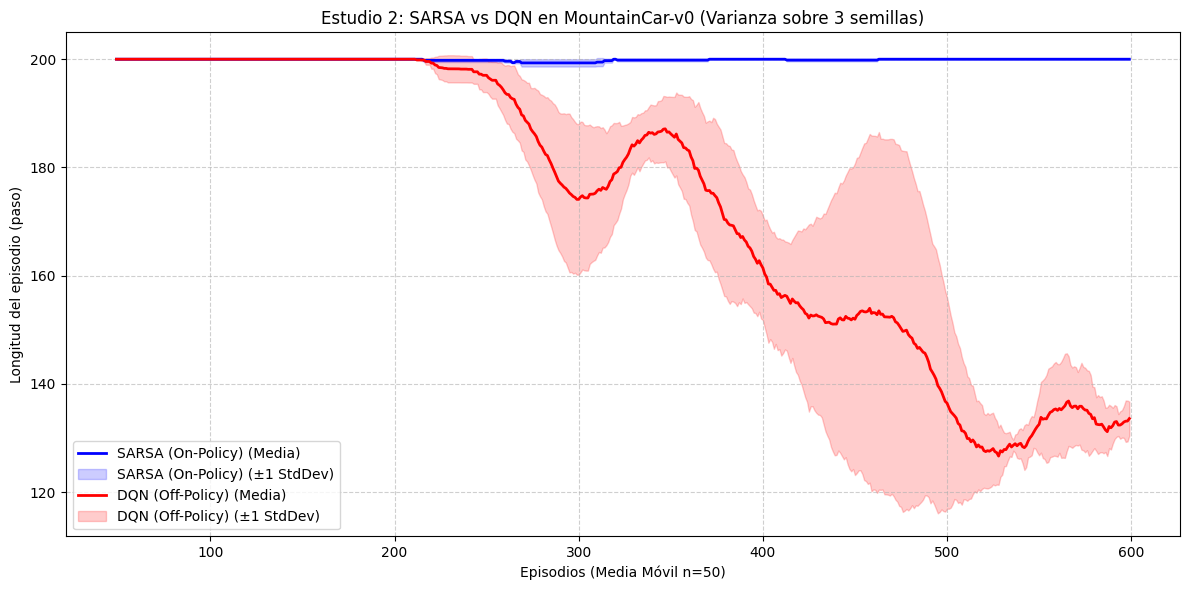

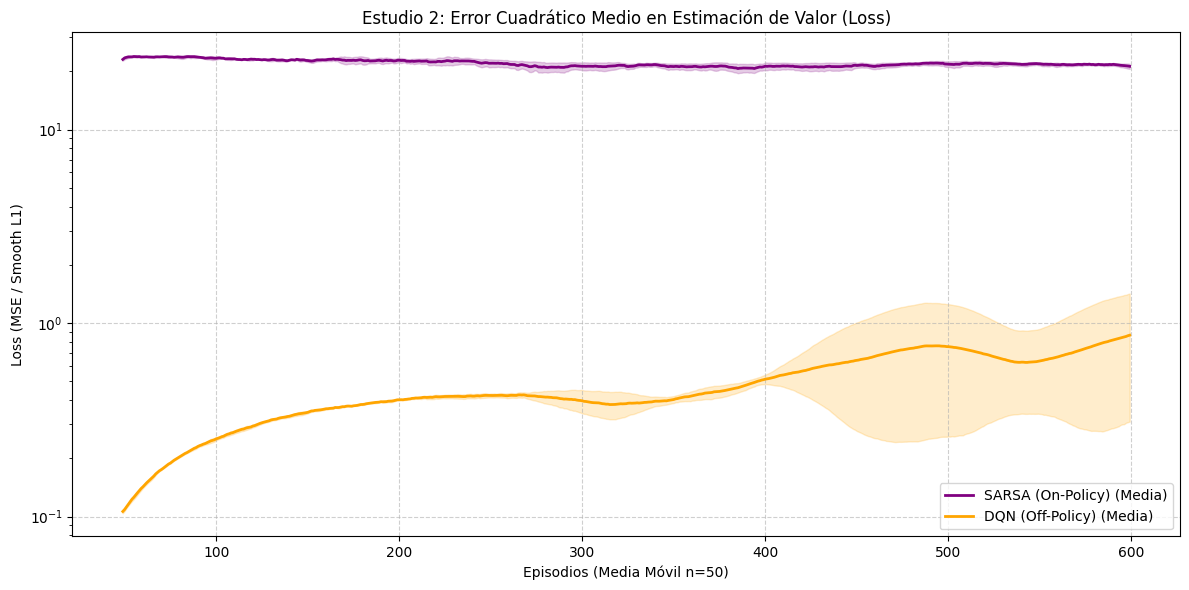

In [ ]:
# Estudio 2: SARSA (agente 1) vs DQN

n_semillas = 3
episodios = 600
semillas = [1, 12, 123]

resultados_estudio_2 = {}
losses_estudio_2 = {} # Diccionario para guardar el Error (Loss)

# Configuraciones de los algoritmos
algoritmos = {
    "SARSA (On-Policy)": (AgentSarsaSemiGradient_Estudio2, {'gamma': 0.99, 'lr': 0.001}),
    "DQN (Off-Policy)": (AgentDQN_ConLoss, {
        'gamma': 0.99,
        'lr': 0.001,
        'batch_size': 64,
        'target_update_freq': 200,
        'buffer_capacity': 10000
    })
}

for nombre_algo, (clase_agente, hyperparams) in algoritmos.items():
    print(f"\n=== Entrenando {nombre_algo} ===")
    matriz_resultados = np.zeros((n_semillas, episodios))
    matriz_losses = np.zeros((n_semillas, episodios)) # Matriz para el Loss

    for i, seed in enumerate(semillas):
        set_seed(seed)
        env = make_env("MountainCar-v0", seed=seed)

        # Inicializamos el hiperparámetro epsilon base
        hyperparams['epsilon'] = 1.0
        agente = clase_agente(env, hyperparams)

        # Entrenamos (Decay de 0.01 para asegurar buena exploración inicial en ambos)
        stats = train_agent(
            env=env,
            agent=agente,
            n_episodes=episodios,
            initial_eps=1.0,
            final_eps=0.01,
            decay_rate=0.01
        )

        matriz_resultados[i] = stats["episode_lengths"]

        # Extraemos el loss de la variable aislada de nuestra subclase
        matriz_losses[i] = agente.historial_losses_episodios

        env.close()

    resultados_estudio_2[nombre_algo] = matriz_resultados
    losses_estudio_2[nombre_algo] = matriz_losses # Lo añadimos al diccionario de losses

# 1. Visualización comparativa de rendimiento (Longitud del episodio)
plot_multiple_seeds_rewards2(
    resultados_estudio_2,
    window_size=50,
    title=f"Estudio 2: SARSA vs DQN en MountainCar-v0 (Varianza sobre {n_semillas} semillas)"
)

# 2. Visualización comparativa de estabilidad (TD Error / Loss)
plot_value_estimation_error(
    losses_estudio_2,
    window_size=50,
    title="Estudio 2: Error Cuadrático Medio en Estimación de Valor (Loss)"
)

**GRÁFICA ERROR CUADRÁTICO MEDIO ESTUDIO 2**

Si observamos la evolución del Error Cuadrático Medio, la diferencia de estabilidad entre ambos agentes es clara y explica por qué SARSA no lograba aprender. SARSA, al actualizar sus pesos paso a paso persigue un objetivo en constante movimiento (calcula el error utilizando su propia red que está cambiando en ese mismo instante).  

En cambio DQN logra mantener el error bajo control gracias a su Target Network. Al congelar los pesos de esta red secundaria durante varios pasos, DQN tiene metas fijas para calcular el error. Si a esto le sumamos el Experience Replay, que mezcla experiencias pasadas para romper la correlación del tiempo, el resultado es un descenso del gradiente mucho más suave.


=== Evaluando DQN (Buffer = 10000) - Estable ===
Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [05:04<00:00,  1.97it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [04:39<00:00,  2.15it/s]


Usando dispositivo: cpu


...

Entrenando agente: 100%|██████████| 600/600 [04:30<00:00,  2.22it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [04:43<00:00,  2.12it/s]


Usando dispositivo: cpu


Entrenando agente: 100%|██████████| 600/600 [04:43<00:00,  2.12it/s]


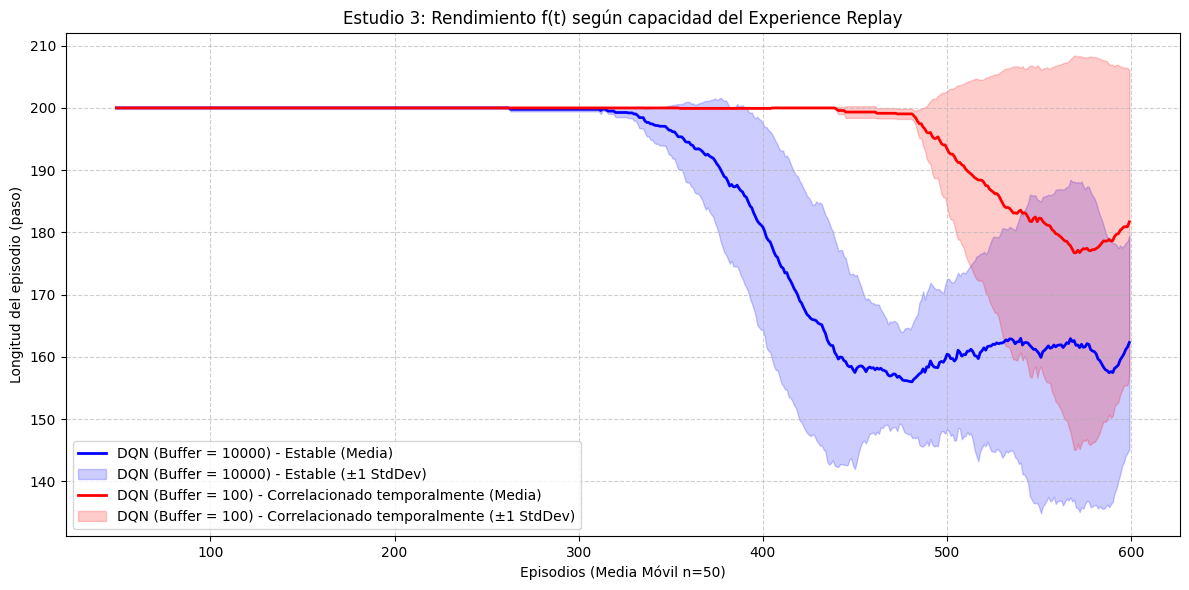

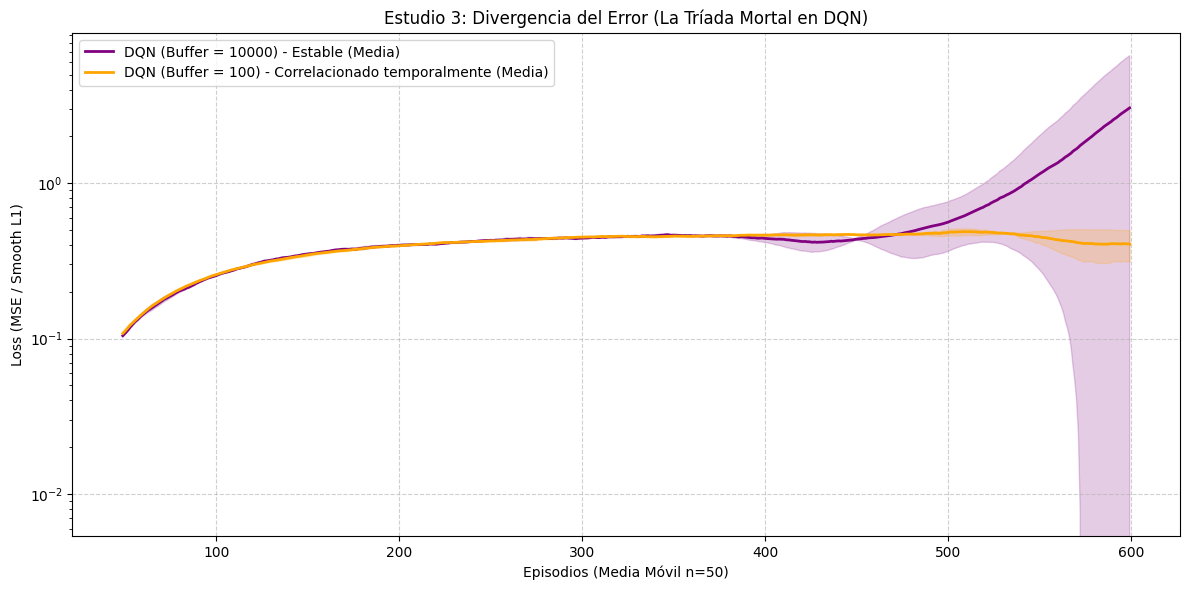

In [ ]:
# Estudio 3: tocando Experience Replay

n_semillas = 3
episodios = 600  # Con 600 episodios es suficiente
semillas = [1, 12, 123]

resultados_estudio_3 = {}
losses_estudio_3 = {} # Diccionario para guardar el Error (Loss)

# Configuraciones de capacidad de memoria
configuraciones_buffer = {
    "DQN (Buffer = 10000) - Estable": 10000,
    "DQN (Buffer = 100) - Correlacionado temporalmente": 100
}

for nombre_conf, capacidad in configuraciones_buffer.items():
    print(f"\n=== Evaluando {nombre_conf} ===")
    matriz_resultados = np.zeros((n_semillas, episodios))
    matriz_losses = np.zeros((n_semillas, episodios)) # Matriz para el Loss

    for i, seed in enumerate(semillas):
        set_seed(seed)
        env = make_env("MountainCar-v0", seed=seed)

        # Inyectamos la capacidad simplificada o estándar
        hyperparams = {
            'gamma': 0.99,
            'lr': 0.001,
            'batch_size': 64,
            'target_update_freq': 200,
            'buffer_capacity': capacidad,
            'epsilon': 1.0
        }
        # Usamos nuestra subclase aislada
        agente = AgentDQN_ConLoss(env, hyperparams)

        # Entrenamos
        stats = train_agent(
            env=env,
            agent=agente,
            n_episodes=episodios,
            initial_eps=1.0,
            final_eps=0.01,
            decay_rate=0.01
        )

        matriz_resultados[i] = stats["episode_lengths"]

        matriz_losses[i] = agente.historial_losses_episodios

        env.close()

    resultados_estudio_3[nombre_conf] = matriz_resultados
    losses_estudio_3[nombre_conf] = matriz_losses # Lo añadimos al diccionario de losses

# 1. Visualización del colapso del aprendizaje (Longitud del episodio)
plot_multiple_seeds_rewards2(
    resultados_estudio_3,
    window_size=50,
    title="Estudio 3: Rendimiento f(t) según capacidad del Experience Replay"
)

# 2. Visualización de la divergencia del valor (Loss)
plot_value_estimation_error(
    losses_estudio_3,
    window_size=50,
    title="Estudio 3: Divergencia del Error (La Tríada Mortal en DQN)"
)

**GRÁFICA ERROR CUADRÁTICO MEDIO ESTUDIO 3**

En la primera gráfica se ve como con un buffer grande el agente logra estabilizarse y llegar a la meta en menos pasos a partir del episodio 300. Esto ocurre porque al tener una memoria amplia, puede entrenar mezclando experiencias variadas, lo que rompe la dependencia que hay entre un paso y el siguiente. Con un buffer pequeño de 100, el agente es inestable y acaba rindiendo mal. En cuanto aprende a moverse en una zona nueva del entorno, olvida cómo comportarse en las zonas por las que pasó antes.


La segunda gráfica sobre la evolución del error nos resulta algo extraña. El agente con el buffer pequeño mantiene un error bajo y estable, pero no porque lo haga bien, sino porque está atascado recibiendo castigos constantemente y se ha vuelto bueno prediciendo que le va a ir mal. En cambio el agente del buffer grande ve cómo su error se sube justo en el momento en el que empieza a resolver el entorno. Creemos que esto ocurre porque el agente ha descubierto la meta y está reestructurando de golpe toda la red neuronal para adaptarse a esa nueva información positiva.

### **Conclusiones de los estudios realizados**




- En el **Estudio 1** hemos visto que la inestabilidad de un agente no siempre está en la hiperparametrización (como la política de exploración ϵ-greedy) o en pequeños sesgos de estimación, y que usar de métodos online como SARSA semi-gradiente no funciona debido a la fuerte correlación temporal de las secuencias, lo que lleva a la red al olvido catastrófico.

- En el **Estudio 2** hemos evidenciado la superioridad de las arquitecturas Off-Policy. Al introducir DQN hemos logrado resolver el entorno gracias a la combinación de Target Network y el Experience Replay, mecanismos que acaban con la dependencia secuencial de los datos, permitiendo un descenso del gradiente estable.

- En el **Estudio 3** hemos profundizado un poco en el funcionamiento interno de DQN, demostrando que la memoria es un requisito para la estabilidad. Al reducir el buffer forzamos el colapso del agente y observamos un fenómeno extraño en la función de pérdida: el agente con bajo buffer converge a un error bajo por su pesimismo, mientras que el agente con más buffer tiene un pico de error al descubrir la meta. Esto muestra cómo las redes neuronales reestructuran sus pesos ante recompensas atípicas.